In [81]:
import umap

import pandas as pd

from sklearn.manifold import TSNE


In [82]:
data = pd.read_csv("./data/DataModel.csv", sep=",")

In [83]:
data

,Year,Category,Region,Dist_EQ,PCT_CHARTER,PCT_NETWORK,PCT_REGIONAL,PCT_LCC
0,2002,NBI,AFRMY,1016.778341,0.059713,0.622493,0.267125,0.050669
1,2002,NBI,AMCS,1048.401762,0.000000,0.600042,0.377531,0.022427
2,2002,NBI,AMN,1409.858140,0.017363,0.590396,0.173806,0.218435
3,2002,NBI,ASIAUS,731.613261,0.000000,0.469682,0.466558,0.063759
4,2002,NBI,CEI,2021.616697,0.101249,0.335923,0.353537,0.209291
...,...,...,...,...,...,...,...,...
547,2024,NBS,ASIAUS,812.959679,0.005828,0.090262,0.756055,0.147855
548,2024,NBS,CEI,1639.145589,0.123707,0.000000,0.861040,0.015253
549,2024,NBS,CHN,1167.965411,0.000000,0.499884,0.446786,0.053330
550,2024,NBS,EUR,931.780060,0.033287,0.389731,0.127346,0.449636


In [84]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Prepare data - select all numerical features
numerical_features = [
    "Dist_EQ",
    "PCT_CHARTER",
    "PCT_NETWORK",
    "PCT_REGIONAL",
    "PCT_LCC",
    "Year",
]
X = data[numerical_features].to_numpy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode Category for shape
le_cat = LabelEncoder()
category_encoded = le_cat.fit_transform(data["Category"])

# Encode Region for coloring
le_reg = LabelEncoder()
region_encoded = le_reg.fit_transform(data["Region"])

Computing t-SNE...


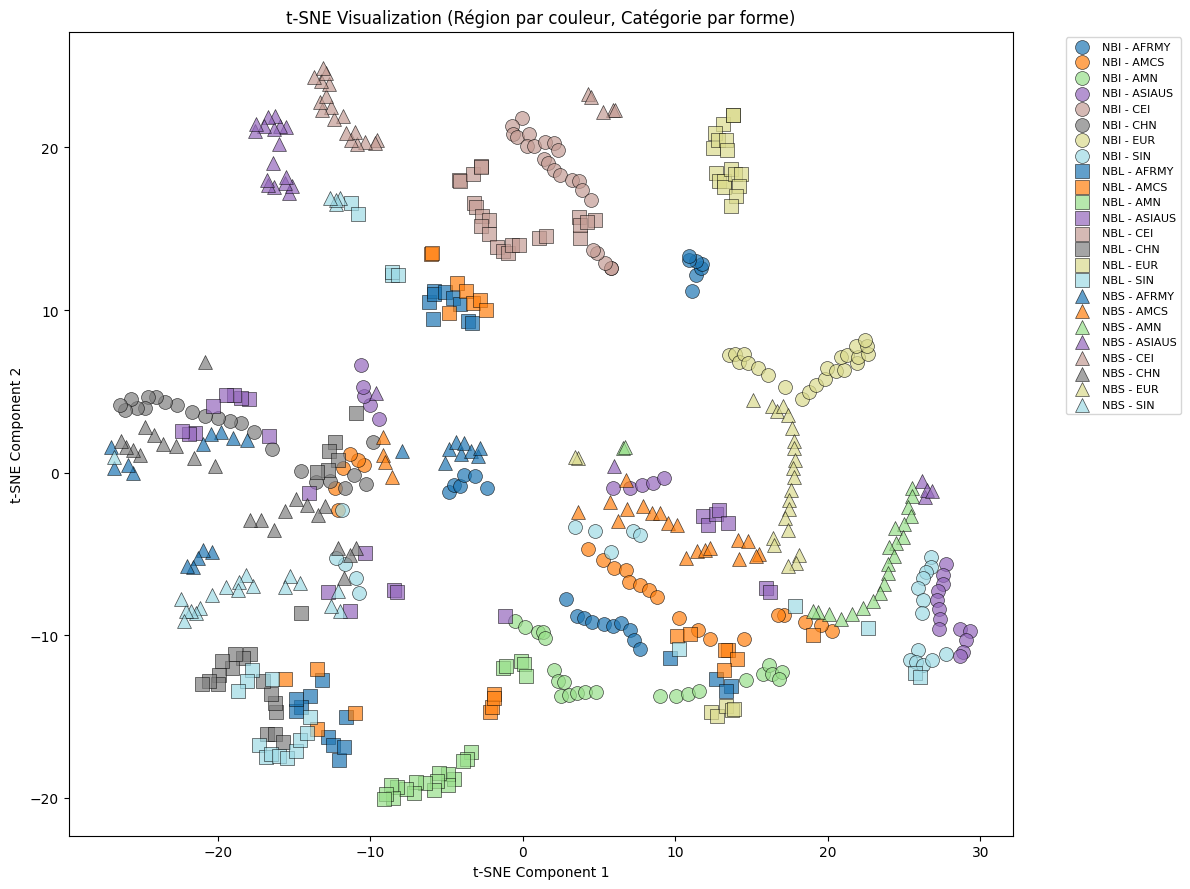

Categories: ['NBI' 'NBL' 'NBS']
Regions: ['AFRMY' 'AMCS' 'AMN' 'ASIAUS' 'CEI' 'CHN' 'EUR' 'SIN']
Markers: Circle=NBI, Square=NBL, Triangle=NBS


In [85]:
# t-SNE visualization
print("Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE with region colors and category shapes
fig, ax = plt.subplots(figsize=(12, 9))

# Define shapes (markers) for each category
markers = {0: "o", 1: "s", 2: "^"}  # circle, square, triangle
colors = plt.cm.tab20(np.linspace(0, 1, len(le_reg.classes_)))

# Plot each combination of category and region
for cat in np.unique(category_encoded):
    for reg in np.unique(region_encoded):
        mask = (category_encoded == cat) & (region_encoded == reg)
        ax.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            c=[colors[reg]],
            marker=markers[cat],
            s=100,
            alpha=0.7,
            edgecolors="black",
            linewidth=0.5,
            label=f"{le_cat.classes_[cat]} - {le_reg.classes_[reg]}",
        )

ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_title("t-SNE Visualization (Région par couleur, Catégorie par forme)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Categories: {le_cat.classes_}")
print(f"Regions: {le_reg.classes_}")
print("Markers: Circle=NBI, Square=NBL, Triangle=NBS")

Computing UMAP...


/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


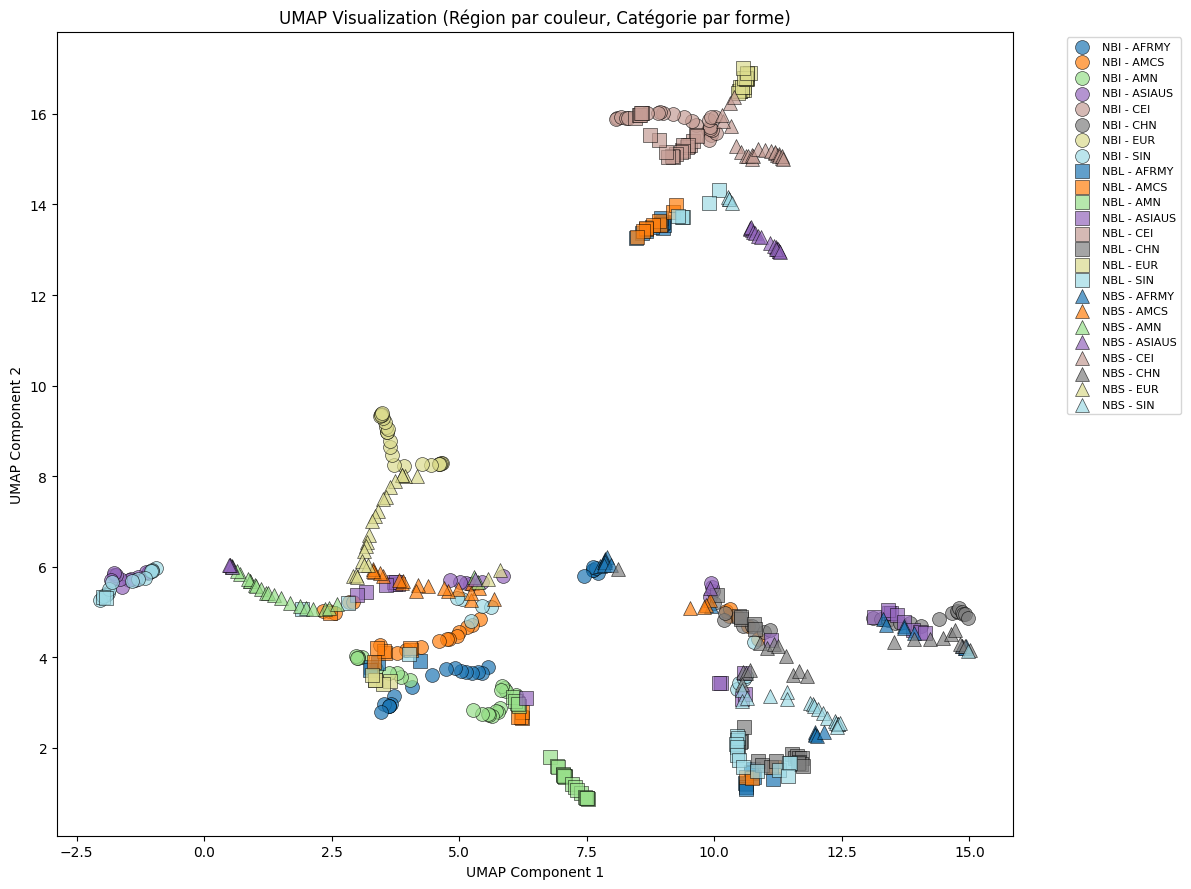

In [86]:
# UMAP visualization with different parameters
print("Computing UMAP...")
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_reducer.fit_transform(X_scaled)

# Plot UMAP with region colors and category shapes
fig, ax = plt.subplots(figsize=(12, 9))

# Define shapes (markers) for each category
markers = {0: "o", 1: "s", 2: "^"}  # circle, square, triangle
colors = plt.cm.tab20(np.linspace(0, 1, len(le_reg.classes_)))

# Plot each combination of category and region
for cat in np.unique(category_encoded):
    for reg in np.unique(region_encoded):
        mask = (category_encoded == cat) & (region_encoded == reg)
        ax.scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            c=[colors[reg]],
            marker=markers[cat],
            s=100,
            alpha=0.7,
            edgecolors="black",
            linewidth=0.5,
            label=f"{le_cat.classes_[cat]} - {le_reg.classes_[reg]}",
        )

ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")
ax.set_title("UMAP Visualization (Région par couleur, Catégorie par forme)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()